---

## NOTEBOOK 03 : DBSCAN - CLASSIFICATION AVEC DBSCAN

---

---

## Description

    Ce notebook constitue le livrable de la phase de modélisation du projet.
    Il est consacré à l'application de l'algorithme DBSCAN pour la classification des
    donnees et la détection des potentielles anomalies dans les transactions bancaires.

    OBJECTIFS:
    ----------
        - Entraîner un modèle DBSCAN sur les données nettoyées
        - Détecter les transactions potentiellement anormales
        - Analyser et visualiser les résultats
        - Interpréter les potentielles anomalies détectées
        - Sauvegarder le modèle pour une utilisation ultérieure

    CONTENU:
    --------
        1. Introduction théorique à DBSCAN
        2. Chargement et préparation des données
        3. Normalisation des variables
        4. Entraînement du modèle DBSCAN
        5. Évaluation et analyse des résultats
        6. Visualisation des Potentielles anomalies
        7. Export des Potentielles anomalies détectées
        8. Synthèse et recommandations

    PRÉREQUIS:
    ----------
        - Notebook 01 exécuté (données nettoyées disponibles)
        - Bibliothèques: pandas, numpy, matplotlib, seaborn, scikit-learn,Prince

---

### SECTION 1 : INTRODUCTION - RAPPEL THÉORIQUE

---

   #### 1.1. PRINCIPE DE L'ALGORITHME DBSCAN
   -----------------------------------------------
   DBSCAN (Density-Based Spatial Clustering of Applications with Noise) est un algorithme de
    clustering basé sur la densité des points.DBSCAN ne nécessite pas de
    spécifier le nombre de clusters à l’avance; à la place, il nécessite deux hyperparamètres propres :
    ε(epsilon) et minPts.

   FONDEMENT THÉORIQUE :

      - Les anomalies sont rares et différentes
      - La classification des points basee sur dansité peut nous aider et isole les arnomalies potentielles
      - L'algorithme construit des groupes ou clusters
      - Les anomalies ont la particulaté de ne pas etre dans aucun groupe

   #### 1.2. AVANTAGES DE L'APPROCHE
   -----------------------------
      - Non supervisé: ne nécessite pas de données étiquetées
      - Pas besoin de spécifier le nombre de clusters à l'avance
      - Détecte les formes de clusters arbitraires:pas besoin d’être sphériques
      - Gère bien le bruit et les outliers : robuste aux valeurs aberrantes  
      - Relativement efficace :Sa complexité moyenne est O(n log n) ou O(n2)

   #### 1.3. HYPERPARAMÈTRES CLÉS
   --------------------------
      -  ε(epsilon) : une distance rayonnant autour d’un point, définissant son voisinage immédiat (ε
        neighborhood)
      - minPts : le nombre minimum de points requis dans le voisinage ε pour que l’on considère
        qu’un point est dans une région suffisamment dense.
      

   #### 1.4. INTERPRÉTATION DES RÉSULTATS
   ----------------------------------
      - Score = -1: Anomalie détectée
      - Score = 1: Transaction normale

---         

### 2 IMPORTATION DES BIBLIOTHEQUES NECESSAIRES

In [1]:
"""
2. IMPORTATION DES BIBLIOTHÈQUES
=================================

Cette section importe toutes les bibliothèques nécessaires pour:
    - La manipulation des données (pandas, numpy)
    - La visualisation (matplotlib, seaborn)
    - La modélisation (scikit-learn)
    - La gestion des fichiers (joblib, pathlib)
    - La gestion des avertissements (warnings)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import yaml
import sklearn
import gc
from datetime import datetime
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from prince import FAMD
from collections import Counter

# Configuration des warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Création des dossiers nécessaires
for folder in ['../models', '../results/figures', '../results/metrics']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("="*60)
print("NOTEBOOK 03 : DBSCAN - CLASSIFICATION")
print("="*60)

print("\nBibliothèques importées avec succès")
print(f"   - Pandas: {pd.__version__}")
print(f"   - NumPy: {np.__version__}")
print(f"   - Matplotlib: {plt.matplotlib.__version__}")
print(f"   - Seaborn: {sns.__version__}")
print(f"   - Scikit-learn: {sklearn.__version__}")  
print(f"   - Joblib: {joblib.__version__}")


NOTEBOOK 03 : DBSCAN - CLASSIFICATION

Bibliothèques importées avec succès
   - Pandas: 3.0.3
   - NumPy: 2.5.1
   - Matplotlib: 3.11.0
   - Seaborn: 0.13.2
   - Scikit-learn: 1.9.0
   - Joblib: 1.5.3


### 3 CHARGEMENT DU DATASET NETTOYE

In [2]:
"""
    Cette section charge le jeu de données nettoyé produit par le Notebook 01.
    Les données sont prêtes pour la modélisation.
"""

def load_cleaned_data(filepath: str) -> pd.DataFrame:
    """
    Charge le jeu de données nettoyé à partir d'un fichier CSV.
    
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV contenant les données nettoyées
        
    Returns
    -------
    pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Raises
    ------
    FileNotFoundError
        Si le fichier spécifié n'existe pas
        
    Examples
    --------
    >>> df = load_cleaned_data('../data/processed/indian_banking_transactions_clean.csv')
    >>> print(df.shape)
    (550000, 20)
    
    Notes
    -----
    Cette fonction suppose que les données ont déjà été nettoyées
    et sont prêtes pour la modélisation.
    """
    
    try:
        df = pd.read_csv(filepath)
        print(f"Données chargées avec succès")
        print(f"   - Fichier: {filepath}")
        print(f"   - Dimensions: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print(f"Erreur: Fichier non trouvé à {filepath}")
        raise
    except Exception as e:
        print(f"Erreur lors du chargement: {str(e)}")
        raise

# Chargement des données
DATA_PATH = '../data/processed/indian_banking_transactions_clean.csv'

try:
    df = load_cleaned_data(DATA_PATH)
    print("\nAperçu des 5 premières lignes:")
    display(df.head())
except Exception as e:
    print(f"Erreur de chargement: {e}")
    df = pd.DataFrame()


Données chargées avec succès
   - Fichier: ../data/processed/indian_banking_transactions_clean.csv
   - Dimensions: 550,000 lignes x 20 colonnes

Aperçu des 5 premières lignes:


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,Unknown,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,Unknown,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,Unknown,0.00,Success,API,Verified,0,14


### SECTION 4 : SÉLECTION DES VARIABLES POUR LA MODÉLISATION

In [3]:
"""
Cette section sélectionne les variables numériques qui seront utilisées
pour la détection d'anomalies.

VARIABLES SÉLECTIONNÉES:
    - transaction_amount: Montant de la transaction
    - account_balance: Solde du compte
    - credit_score: Score de crédit du client
    - has_loan: Présence d'un prêt (0/1)
    - emi_amount: Montant des mensualités
    - transaction_hour: Heure de la transaction

JUSTIFICATION DES CHOIX:
    - Variables quantitatives continues ou discrètes
    - Variables pertinentes pour la détection d'anomalies
    - Absence de valeurs manquantes significatives
    - Indépendance relative (corrélations faibles)
"""

def select_features(df: pd.DataFrame) -> tuple:
    """
    Sélectionne les variables numériques pour la modélisation.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Returns
    -------
    tuple
        - feature_names: Liste des noms des variables
        - categorical_features: Liste des noms des variables catégorielles
        
    Examples
    --------
    >>> numeric_features, categorical_features = select_features(df)
    >>> print(numeric_features)
    ['transaction_amount', 'account_balance', ...]
    """

    numeric_features = [
        'transaction_amount',
        'account_balance',
        'credit_score',
        'has_loan',
        'emi_amount',
        'transaction_hour'
    ]
    
    categorical_features = [
        'channel',
        'account_type',
        'transaction_type',
        'transaction_direction'
    ]
    
    # Vérifier la présence des colonnes
    all_features = numeric_features + categorical_features
    missing_cols = [col for col in all_features if col not in df.columns]
    if missing_cols:
        print(f"Colonnes manquantes: {missing_cols}")
        raise ValueError(f"Colonnes manquantes: {missing_cols}")
    
    print(f"\nMatrice de données:")
    print(f"   - Lignes: {df.shape[0]:,}")
    print(f"   - Variables numériques: {len(numeric_features)}")
    print(f"   - Variables catégorielles: {len(categorical_features)}")
    
    print("\nVariables numériques sélectionnées:")
    for i, feat in enumerate(numeric_features, 1):
        print(f"   {i}. {feat}")
    
    print("\nVariables catégorielles sélectionnées:")
    for i, feat in enumerate(categorical_features, 1):
        print(f"   {i}. {feat}")
    
    return numeric_features, categorical_features

numeric_features, categorical_features = select_features(df)


Matrice de données:
   - Lignes: 550,000
   - Variables numériques: 6
   - Variables catégorielles: 4

Variables numériques sélectionnées:
   1. transaction_amount
   2. account_balance
   3. credit_score
   4. has_loan
   5. emi_amount
   6. transaction_hour

Variables catégorielles sélectionnées:
   1. channel
   2. account_type
   3. transaction_type
   4. transaction_direction


### SECTION 5: REDUCTION DE DIMENSIONNALITE AVEC AFDM

In [ ]:

# ===============================================================
# FONCTIONS UTILITAIRES
# ===============================================================

def _extract_famd_inertia(famd_model):

    """
    Récupère l'inertie individuelle et l'inertie cumulée
    d'un modèle Prince AFDM.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        inertie_individuelle_pct :
        Pourcentage d'inertie expliqué par chaque composante

        inertie_cumulee_pct :
        Pourcentage d'inertie cumulé
    """

    #=========================================================
    # 1- Récupération de l'inertie individuelle
    #=========================================================

    # Attribut recommandé dans les versions récentes de Prince

    if hasattr(famd_model, "percentage_of_variance_"):
        inertie_individuelle = np.asarray(
            famd_model.percentage_of_variance_,
            dtype=float,
        ).reshape(-1)

    # Compatibilité avec certaines anciennes versions
    elif hasattr(famd_model, "explained_inertia_"):
        inertie_individuelle = np.asarray(
            famd_model.explained_inertia_,
            dtype=float,
        ).reshape(-1)

        # explained_inertia_ est généralement exprimé entre 0 et 1
        # donc, on multiplie par 100 pour uniformiser les calcules
        inertie_individuelle = inertie_individuelle * 100

    # erreur en cas d'echec
    else:
        raise RuntimeError(
            "Impossible de récupérer l'inertie expliquée. "
            "La version installée de prince ne fournit ni "
            "'percentage_of_variance_' ni 'explained_inertia_'."
        )

    #=========================================================
    # 2- Récupération de l'inertie cumulative
    #=========================================================

    # Inertie cumulative fournie directement par Prince
    if hasattr(famd_model, "cumulative_percentage_of_variance_"):
        inertie_cumulee = np.asarray(
            famd_model.cumulative_percentage_of_variance_,
            dtype=float,
        ).reshape(-1)

    else:
        inertie_cumulee = np.cumsum(inertie_individuelle)

    if len(inertie_individuelle) != len(inertie_cumulee):
        raise RuntimeError(
            "Les tailles des inerties individuelle et cumulée "
            "sont incohérentes."
        )

    if not np.all(np.isfinite(inertie_individuelle)):
        raise RuntimeError(
            "L'inertie individuelle contient des valeurs "
            "NaN ou infinies."
        )

    if not np.all(np.isfinite(inertie_cumulee)):
        raise RuntimeError(
            "L'inertie cumulée contient des valeurs "
            "NaN ou infinies."
        )

    return inertie_individuelle, inertie_cumulee


def _detect_elbow(inertie_individuelle):
    """
    Détecte un coude sur la courbe d'inertie individuelle.

    La méthode calcule la distance maximale entre la courbe normalisée
    et la droite reliant le premier et le dernier point.

    Parameters
    ----------
    inertie_individuelle : array-like
        Inertie expliquée par chaque composante

    Returns
    -------
    int | None
        Numéro de la composante correspondant au coude
    """

    #===================================================
    # on force un vecteur Numpy  de floats
    #===================================================
    inertie_individuelle = np.asarray(
        inertie_individuelle,
        dtype=float,
    ).reshape(-1)
    # nombre de composantes
    nombre_composantes = len(inertie_individuelle)

    #===========================================================   
    # Cas limites qui ne permettent pas de détecter un coude
    #===========================================================

    # nombres de composant inferieur a 3
    if nombre_composantes < 3:
        return None

    if np.allclose(
        inertie_individuelle,
        inertie_individuelle[0],
    ):
        return None

    #========================================================
    # Construction des coordonnées
    #========================================================
    x = np.arange(
    1,
    nombre_composantes + 1,
    dtype=float,
    )

    y = inertie_individuelle.copy()
    #========================================================
    # Normalisation entre 0 et 1 afin que l'échelle des axes
    # n'influence pas excessivement la détection du coude
    #========================================================
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()

    if x_range == 0 or y_range == 0:
        return None

    x_normalise = (x - x.min()) / x_range
    y_normalise = (y - y.min()) / y_range

#========================================================
# Construction géométrique de la droite de référence
#========================================================
    points = np.column_stack(
        (x_normalise, y_normalise)
    )

    premier_point = points[0]
    dernier_point = points[-1]

    vecteur_droite = dernier_point - premier_point
    norme_droite = np.linalg.norm(vecteur_droite)

    if norme_droite == 0:
        return None

    vecteurs_points = points - premier_point

    distances = np.abs(
        vecteur_droite[0] * vecteurs_points[:, 1]
        - vecteur_droite[1] * vecteurs_points[:, 0]
    ) / norme_droite
    #===============================================================
    # Exclusion des extrémités
    # Les extrémités ne doivent pas être considérées comme un coude
    #================================================================
    distances[0] = 0
    distances[-1] = 0

    position_coude = int(np.argmax(distances))

    if distances[position_coude] == 0:
        return None

    # +1, car les composantes commencent à 1
    return position_coude + 1


# ===============================================================
# FONCTION PRINCIPALE
# ===============================================================

def reduce_dimensions_afdm(
    df,
    numeric_features,
    categorical_features,
    n_components=5,
    sample_size=None,
    random_state=42,
    diagnostic_mode=False,
    diagnostic_max_components=30,
    target_inertia=50.0,
    n_iter=5,
    high_cardinality_threshold=1_000,
    output_dtype="float32",
    show_plots=True,
):
    """
    Entraîne une AFDM , puis transforme le dataset complet.

    Lorsque diagnostic_mode=True, la fonction :

    1. entraîne une AFDM avec plusieurs composantes ;
    2. calcule l'inertie individuelle ;
    3. calcule l'inertie cumulative ;
    4. recherche un coude ;
    5. recherche le nombre minimal de composantes atteignant
       target_inertia ;
   

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset contenant les données originales.

    numeric_features : list[str]
        Noms des variables numériques.

    categorical_features : list[str]
        Noms des variables catégorielles.

    n_components : int, default=5
        Nombre de composantes utilisées lors de l'entraînement normal.

    sample_size : int, default=550_000
        Nombre maximal de lignes utilisées pour entraîner l'AFDM.

    random_state : int, default=42
        Graine utilisée pour rendre l'échantillonnage reproductible.

    diagnostic_mode : bool, default=False
        Active le mode de recherche du nombre de composantes.

    diagnostic_max_components : int, default=30
        Nombre maximal de composantes calculées en mode diagnostic.

    target_inertia : float, default=50.0
        Seuil d'inertie cumulée recherché, exprimé en pourcentage.

    n_iter : int, default=5
        Nombre d'itérations utilisées par la décomposition.

    high_cardinality_threshold : int, default=1_000
        Seuil à partir duquel une variable catégorielle est considérée
        comme ayant une forte cardinalité.

    output_dtype : str | None, default="float32"
        Type des coordonnées finales. Utiliser None pour conserver
        le type retourné par Prince.

    show_plots : bool, default=True
        Affiche les graphiques en mode diagnostic.

    Returns
    -------
    En mode normal
    --------------
    X_reduced : pandas.DataFrame
        Coordonnées AFDM du dataset complet.

    famd : prince.FAMD
        Modèle AFDM entraîné.

    En mode diagnostic
    ------------------
    diagnostic_results : dict
        Résultats du diagnostic.

    famd_diag : prince.FAMD
        Modèle AFDM utilisé pour le diagnostic.
    """

    # ==========================================================
    # Validation générale des paramètres
    # ==========================================================

    if not isinstance(df, pd.DataFrame):
        raise TypeError(
            "df doit être un pandas.DataFrame."
        )

    if df.empty:
        raise ValueError(
            "Le DataFrame fourni est vide."
        )

   
    # Recuperation et validation des features
    
    numeric_features = list(numeric_features)
    categorical_features = list(categorical_features)

    selected_features = (
        numeric_features + categorical_features
    )

    if not numeric_features:
        raise ValueError(
            "L'AFDM exige au moins une variable numérique."
        )

    if not categorical_features:
        raise ValueError(
            "L'AFDM exige au moins une variable catégorielle."
        )

    
    if sample_size is not None:
        if not isinstance(sample_size, int) or isinstance(sample_size, bool) or sample_size < 2:
            raise ValueError(
                "sample_size doit être None ou un entier supérieur ou égal à 2."
            )

    if not isinstance(n_iter, int) or n_iter < 1:
        raise ValueError(
            "n_iter doit être un entier supérieur ou égal à 1."
        )

    if (
        not isinstance(
            diagnostic_max_components,
            int,
        )
        or diagnostic_max_components < 2
    ):
        raise ValueError(
            "diagnostic_max_components doit être un entier "
            "supérieur ou égal à 2."
        )

    if not 0 < float(target_inertia) <= 100:
        raise ValueError(
            "target_inertia doit être compris entre 0 et 100."
        )

    if (
        not isinstance(
            high_cardinality_threshold,
            int,
        )
        or high_cardinality_threshold < 1
    ):
        raise ValueError(
            "high_cardinality_threshold doit être un entier positif."
        )

    if not diagnostic_mode:
        if (
            not isinstance(n_components, int)
            or isinstance(n_components, bool)
            or n_components < 1
        ):
            raise ValueError(
                "n_components doit être un entier supérieur "
                "ou égal à 1."
            )

    # ===========================================================
    # Recherche des doublons et colonnes absentes
    # ===========================================================

    feature_counts = Counter(selected_features)

    duplicated_features = sorted(
        feature
        for feature, count in feature_counts.items()
        if count > 1
    )

    if duplicated_features:
        raise ValueError(
            "Variables présentes plusieurs fois : "
            f"{duplicated_features}"
        )

    missing_features = [
        feature
        for feature in selected_features
        if feature not in df.columns
    ]

    if missing_features:
        raise KeyError(
            "Colonnes absentes du DataFrame : "
            f"{missing_features}"
        )

    # ===========================================================
    # Copie des variables nécessaires
    # ===========================================================
      

    X_brut = df.loc[
        :,
        selected_features,
    ].copy()

    # ============================================================
    # Nettoyage des variables numériques
    # ============================================================

    numeric_fill_values = {}

    for col in numeric_features:

        X_brut[col] = pd.to_numeric(
            X_brut[col],
            errors="coerce",
        )

        median_value = X_brut[col].median()

        if pd.isna(median_value):
            raise ValueError(
                f"La variable numérique '{col}' ne contient "
                "aucune valeur numérique exploitable."
            )

        numeric_fill_values[col] = float(median_value)

        X_brut[col] = (
            X_brut[col]
            .fillna(median_value)
            .astype("float32")
        )

    # ==========================================================
    # Nettoyage des variables catégorielles
    # ==========================================================

    for col in categorical_features:

        X_brut[col] = (
            X_brut[col]
            .astype("string")
            .fillna("__MANQUANT__")
            .astype(str)
        )

    # ==========================================================
    # Diagnostic des variables constantes
    # ==========================================================

    unique_counts = X_brut[
        selected_features
    ].nunique(dropna=False)

    constant_features = unique_counts[
        unique_counts <= 1
    ].index.tolist()

    if constant_features:
        print(
            "\nAVERTISSEMENT : les variables suivantes sont "
            "constantes et n'apportent aucune information :"
        )

        for feature in constant_features:
            print(f" - {feature}")

    # ==========================================================
    # Diagnostic de cardinalité
    # ==========================================================

    cardinalities = X_brut[
        categorical_features
    ].nunique(dropna=False)

    total_modalities = int(
        cardinalities.sum()
    )

    print(
        "\nCardinalité des variables catégorielles :"
    )

    print(
        cardinalities.sort_values(
            ascending=False
        ).to_string()
    )

    print(
        "\nNombre total de modalités catégorielles : "
        f"{total_modalities:,}"
    )

    high_cardinality = cardinalities[
        cardinalities
        > high_cardinality_threshold
    ]

    if not high_cardinality.empty:

        print(
            "\nAVERTISSEMENT : variables catégorielles "
            "à forte cardinalité :"
        )

        print(
            high_cardinality.sort_values(
                ascending=False
            ).to_string()
        )

        print(
            "\nVérifiez que ces variables ne sont pas "
            "des identifiants, des numéros de compte, "
            "des références uniques ou des horodatages."
        )

    # ====================================================================
    # Données
    # ====================================================================

    
    actual_sample_size = (
        len(X_brut)
        if sample_size is None
        else min(sample_size, len(X_brut))
    )

    if actual_sample_size < len(X_brut):

        df_sample = X_brut.sample(
            n=actual_sample_size,
            random_state=random_state,
        )

    else:
        df_sample = X_brut

    print(
        "\nTaille du dataset complet : "
        f"{len(X_brut):,} observations"
    )

    print(
        "Taille de l'échantillon d'entraînement : "
        f"{len(df_sample):,} observations"
    )

    

    full_category_counts = X_brut[
        categorical_features
    ].nunique(dropna=False)

    sample_category_counts = df_sample[
        categorical_features
    ].nunique(dropna=False)

    unknown_category_counts = (
        full_category_counts
        - sample_category_counts
    )

    unknown_category_counts = (
        unknown_category_counts[
            unknown_category_counts > 0
        ]
    )

    if not unknown_category_counts.empty:

        print(
            "\nCatégories présentes dans le dataset complet "
            "mais absentes de l'échantillon :"
        )

        print(
            unknown_category_counts.sort_values(
                ascending=False
            ).to_string()
        )

        print(
            "\nCes catégories seront ignorées lors de la "
            "transformation grâce à handle_unknown='ignore'."
        )

    # =============================================================
    # Estimation de la borne supérieure du rang
    # =============================================================

    # Pour une variable catégorielle comportant k modalités,
    # le nombre maximal de dimensions indépendantes est k - 1.
    categorical_rank_upper_bound = int(
        (
            sample_category_counts - 1
        )
        .clip(lower=0)
        .sum()
    )

    theoretical_rank_upper_bound = (
        len(numeric_features)
        + categorical_rank_upper_bound
    )

    rank_upper_bound = min(
        len(df_sample) - 1,
        theoretical_rank_upper_bound,
    )

    if rank_upper_bound < 1:
        raise ValueError(
            "Les données ne possèdent pas suffisamment "
            "de variabilité pour entraîner une AFDM."
        )

    print(
        "\nBorne supérieure estimée du rang AFDM : "
        f"{rank_upper_bound}"
    )

    # ===========================================================
    # MODE DIAGNOSTIC
    # ===========================================================

    if diagnostic_mode:

        max_components = min(
            diagnostic_max_components,
            rank_upper_bound,
        )

        if max_components < 2:
            raise ValueError(
                "Le dataset ne possède pas suffisamment de "
                "dimensions pour réaliser un diagnostic."
            )

        print( f"{'='*60}")

        print(
            "MODE DIAGNOSTIC : CHOIX DE n_components")

        print(
            f"{'='*60}"
        )

        print(
            "Nombre de composantes calculées : "
            f"{max_components}"
        )

        print(
            "Seuil d'inertie recherché : "
            f"{target_inertia:.1f} %"
        )

        famd_diag = FAMD(
            n_components=max_components,
            n_iter=n_iter,
            random_state=random_state,
            handle_unknown="ignore",
            engine="sklearn",
        )

        famd_diag.fit(df_sample)

        (
            inertie_individuelle,
            inertie_cumulee,
        ) = _extract_famd_inertia(
            famd_diag
        )

        composantes = np.arange(
            1,
            len(inertie_individuelle) + 1,
        )

        diagnostic_table = pd.DataFrame(
            {
                "n_components": composantes,
                "inertie_individuelle_pct":
                    inertie_individuelle,
                "inertie_cumulee_pct":
                    inertie_cumulee,
            }
        )

        # =======================================================
        # Détection du coude
        # =======================================================

        elbow_component = _detect_elbow(
            inertie_individuelle
        )

        # =======================================================
        # Recherche du seuil d'inertie cumulée
        # =======================================================

        threshold_positions = np.flatnonzero(
            inertie_cumulee
            >= target_inertia
        )

        if len(threshold_positions) > 0:
            threshold_component = int(
                threshold_positions[0] + 1
            )
        else:
            threshold_component = None

        # =======================================================
        # Proposition heuristique
        # =======================================================

        if elbow_component is not None:
            recommended_n_components = (
                elbow_component
            )

        elif threshold_component is not None:
            recommended_n_components = (
                threshold_component
            )

        else:
            recommended_n_components = (
                max_components
            )

        # Valeurs candidates pour les essais DBSCAN
        candidate_components = set()

        if elbow_component is not None:

            for difference in [-2, -1, 0, 1, 2]:

                candidate = (
                    elbow_component
                    + difference
                )

                if 2 <= candidate <= max_components:
                    candidate_components.add(
                        candidate
                    )

        if threshold_component is not None:
            candidate_components.add(
                threshold_component
            )

        candidate_components.add(
            recommended_n_components
        )

        candidate_components = sorted(
            candidate_components
        )

        # =======================================================
        # Graphiques
        # =======================================================

        if show_plots:
            #=======================================================
            # Graphique 1 : inertie individuelle
            #=======================================================

            plt.figure(figsize=(10, 5))

            plt.plot(
                composantes,
                inertie_individuelle,
                marker="o",
                linestyle="--",
            )

            if elbow_component is not None:

                plt.axvline(
                    elbow_component,
                    linestyle=":",
                    label=(
                        "Coude : "
                        f"{elbow_component}"
                    ),
                )

            plt.title(
                "AFDM — inertie expliquée par composante"
            )

            plt.xlabel(
                "Numéro de la composante"
            )

            plt.ylabel(
                "Inertie expliquée (%)"
            )

            plt.grid(True)

            if elbow_component is not None:
                plt.legend()

            plt.tight_layout()
            plt.show()

            #===========================================
            # Graphique 2 : inertie cumulative
            #===========================================

            plt.figure(figsize=(10, 5))

            plt.plot(
                composantes,
                inertie_cumulee,
                marker="o",
                linestyle="--",
            )

            plt.axhline(
                target_inertia,
                linestyle=":",
                label=(
                    "Seuil recherché : "
                    f"{target_inertia:.1f} %"
                ),
            )

            if threshold_component is not None:

                plt.axvline(
                    threshold_component,
                    linestyle=":",
                    label=(
                        "Seuil atteint avec "
                        f"{threshold_component} composantes"
                    ),
                )

            plt.title(
                "AFDM - inertie expliquée cumulée"
            )

            plt.xlabel(
                "Nombre de composantes"
            )

            plt.ylabel(
                "Inertie expliquée cumulée (%)"
            )

            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

        # ========================================================
        # Affichage du tableau
        # ========================================================

        print("\nRésultats de l'inertie expliquée :")

        print(
            diagnostic_table.to_string(
                index=False,
                formatters={
                    "inertie_individuelle_pct":
                        "{:.2f}".format,
                    "inertie_cumulee_pct":
                        "{:.2f}".format,
                },
            )
        )

        print(
            f"{'='*60}"
        )

        print(
            "RÉSUMÉ DU DIAGNOSTIC"
        )

        print(
            f"{'='*60}"
        )

        if elbow_component is not None:

            print(
                "Coude heuristique détecté : "
                f"{elbow_component} composantes"
            )

        else:

            print(
                "Aucun coude clair n'a été détecté."
            )

        if threshold_component is not None:

            print(
                f"{target_inertia:.1f} % d'inertie est atteint "
                f"avec {threshold_component} composantes."
            )

        else:

            print(
                f"{target_inertia:.1f} % d'inertie n'est pas "
                f"atteint avec les {max_components} composantes "
                "calculées."
            )

        print(
            "Suggestion heuristique : "
            f"n_components = {recommended_n_components}"
        )

        print(
            "Valeurs conseillées pour les essais DBSCAN : "
            f"{candidate_components}"
        )


        # Métadonnées ajoutées au modèle diagnostique
        famd_diag.numeric_fill_values_ = (
            numeric_fill_values
        )

        famd_diag.numeric_features_ = (
            numeric_features
        )

        famd_diag.categorical_features_ = (
            categorical_features
        )

        famd_diag.training_sample_size_ = (
            len(df_sample)
        )

        famd_diag.rank_upper_bound_ = (
            rank_upper_bound
        )

        famd_diag.training_cardinalities_ = (
            sample_category_counts.to_dict()
        )

        diagnostic_results = {
            "table": diagnostic_table,
            "elbow_component":
                elbow_component,
            "threshold_component":
                threshold_component,
            "recommended_n_components":
                recommended_n_components,
            "candidate_components":
                candidate_components,
            "target_inertia":
                target_inertia,
            "rank_upper_bound":
                rank_upper_bound,
            "max_components_tested":
                max_components,
            "sample_size":
                len(df_sample),
        }

        return diagnostic_results, famd_diag

    # ===========================================================
    # MODE NORMAL : ENTRAÎNEMENT DE L'AFDM
    # ===========================================================

    if n_components > rank_upper_bound:

        raise ValueError(
            f"n_components={n_components} dépasse la borne "
            f"supérieure estimée du rang ({rank_upper_bound})."
        )

    print(
        f"{'='*60}"
    )

    print(
        "ENTRAÎNEMENT DE L'AFDM"
    )

    print(
        f"{'='*60}"
    )

    print(
        f"Nombre de composantes : {n_components}"
    )

    print(
        "Nombre d'observations d'entraînement : "
        f"{len(df_sample):,}"
    )

    famd = FAMD(
        n_components=n_components,
        n_iter=n_iter,
        random_state=random_state,
        handle_unknown="ignore",
        engine="sklearn",
    )

    famd.fit(df_sample)

    # ===========================================================
    # Conservation des informations de préparation
    # ===========================================================

    famd.numeric_fill_values_ = (
        numeric_fill_values
    )

    famd.numeric_features_ = (
        numeric_features
    )

    famd.categorical_features_ = (
        categorical_features
    )

    famd.training_sample_size_ = (
        len(df_sample)
    )

    famd.rank_upper_bound_ = (
        rank_upper_bound
    )

    famd.training_cardinalities_ = (
        sample_category_counts.to_dict()
    )

    famd.full_cardinalities_ = (
        full_category_counts.to_dict()
    )

    

    if df_sample is not X_brut:

        del df_sample
        gc.collect()

    # ============================================================
    # Transformation complète
    # ============================================================

    print(f"{'='*60}")

    print(
        "\nTransformation de "
        f"{len(X_brut):,} observations..."
    )

    X_reduced = famd.transform(
        X_brut
    )

    # Sécurité au cas où une version de Prince retournerait un tableau numpy
    
    if not isinstance(
        X_reduced,
        pd.DataFrame,
    ):

        X_reduced = pd.DataFrame(
            X_reduced,
            index=df.index,
            columns=[
                f"AFDM_{i + 1}"
                for i in range(n_components)
            ],
        )

    else:
        X_reduced.index = df.index

    # Réduction de la mémoire des coordonnées finales
    if output_dtype is not None:

        X_reduced = X_reduced.astype(
            output_dtype
        )

    print(
        "\nRéduction terminée : "
        f"{X_reduced.shape[0]:,} lignes × "
        f"{X_reduced.shape[1]} composantes."
    )

    del X_brut
    gc.collect()

    return X_reduced, famd




Cardinalité des variables catégorielles :
transaction_type         10
channel                   6
account_type              5
transaction_direction     2

Nombre total de modalités catégorielles : 23

Taille du dataset complet : 550,000 observations
Taille de l'échantillon d'entraînement : 550,000 observations

Borne supérieure estimée du rang AFDM : 25
MODE DIAGNOSTIC : CHOIX DE n_components
Nombre de composantes calculées : 25
Seuil d'inertie recherché : 50.0 %


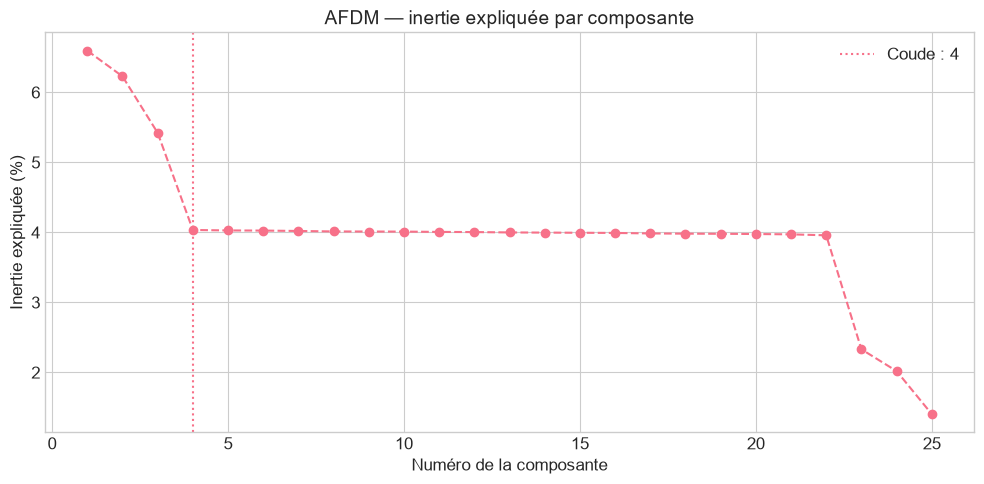

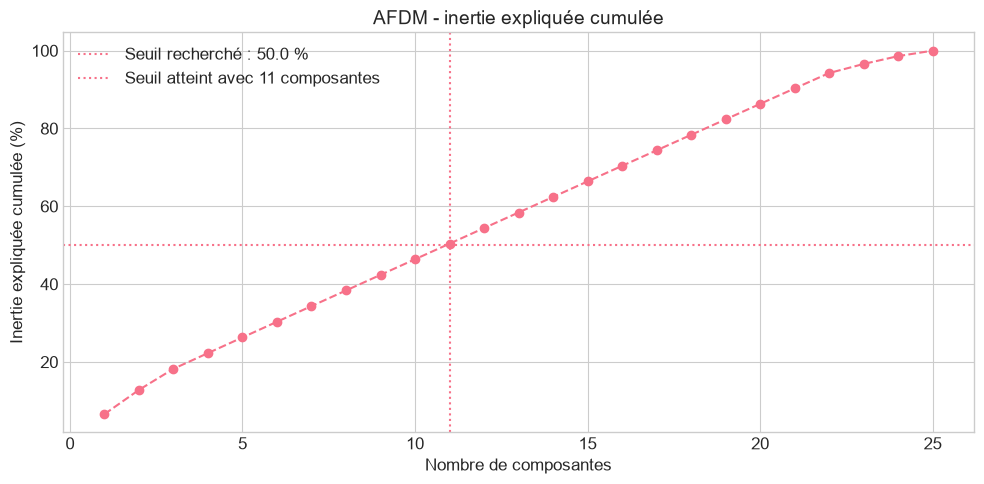


Résultats de l'inertie expliquée :
 n_components inertie_individuelle_pct inertie_cumulee_pct
            1                     6.60                6.60
            2                     6.23               12.82
            3                     5.42               18.25
            4                     4.03               22.28
            5                     4.03               26.31
            6                     4.03               30.34
            7                     4.02               34.36
            8                     4.01               38.37
            9                     4.01               42.38
           10                     4.01               46.39
           11                     4.01               50.40
           12                     4.00               54.41
           13                     4.00               58.41
           14                     4.00               62.40
           15                     3.99               66.40
           16       

In [ ]:
# appel de la fonction reduce_dimensions_afdm, le mode diagnostic activé pour obtenir
# les résultats du diagnostic et le modèle AFDM correspondant.
diagnostic, famd_diag = reduce_dimensions_afdm(
    df,
    numeric_features,
    categorical_features,
    diagnostic_mode=True
)

In [ ]:
n_components = diagnostic["recommended_n_components"]
print(f"Nombre de composantes recommandé : {n_components}")

4


In [ ]:
#  appel de la fonction reduce_dimensions_afdm, le mode normal activé pour obtenir les coordonnées
#  AFDM du dataset complet et le modèle AFDM entraîné.
X_reduced, famd_model = reduce_dimensions_afdm(
    df,
    numeric_features,
    categorical_features,
    n_components=n_components,
    sample_size=None,  
    diagnostic_mode=False
)


Cardinalité des variables catégorielles :
transaction_type         10
channel                   6
account_type              5
transaction_direction     2

Nombre total de modalités catégorielles : 23

Taille du dataset complet : 550,000 observations
Taille de l'échantillon d'entraînement : 550,000 observations

Borne supérieure estimée du rang AFDM : 25
ENTRAÎNEMENT DE L'AFDM
Nombre de composantes : 4
Nombre d'observations d'entraînement : 550,000

Transformation de 550,000 observations...

Réduction terminée : 550,000 lignes × 4 composantes.


#### 5.2. Visualisation de la AFDM

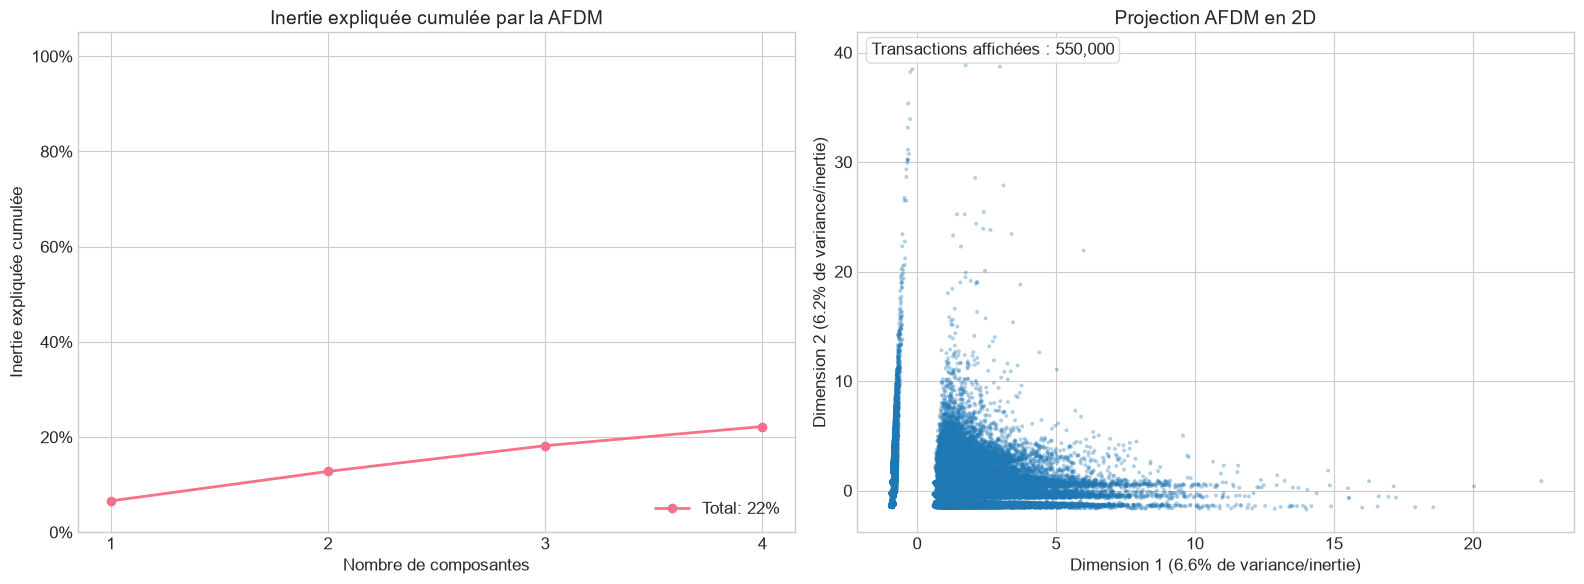

Visualisation FAMD sauvegardée : '../results/figures/famd_projection_2d.png'


In [8]:
"""
Dans cette section, pour justifier le nombre de composantes retenues,
on visualise la projection AFDM en 2D .
"""
def visualize_famd_results(
    X_reduced: pd.DataFrame,
    famd_model,
    sample_size: int = 550000,
    random_state: int = 42
) -> None:

    """
    Affiche la projection AFDM en 2D et la variance expliquée si disponible.
    """
    explained_inertia = getattr(famd_model, 'percentage_of_variance_', None)
    if explained_inertia is not None:
        explained_inertia = np.asarray(explained_inertia, dtype=float) / 100
    else:
        explained_inertia = getattr(famd_model, 'explained_inertia_', None)
        if explained_inertia is not None:
            explained_inertia = np.asarray(explained_inertia, dtype=float)
    if explained_inertia is not None:
        cumulative_variance = np.cumsum(explained_inertia)
        component_numbers = np.arange(1, len(cumulative_variance) + 1)
        variance_threshold = cumulative_variance[-1]
        n_components_threshold = len(explained_inertia)
    else:
        cumulative_variance = None
        component_numbers = None
        variance_threshold = None
        n_components_threshold = X_reduced.shape[1]

    if X_reduced.shape[1] >= 2:
        projection_2d = X_reduced.iloc[:, :2].to_numpy()
        if explained_inertia is not None:
            pc1_variance, pc2_variance = explained_inertia[:2]
        else:
            pc1_variance, pc2_variance = 0.0, 0.0
    else:
        raise ValueError('La visualisation 2D nécessite au moins deux composantes FAMD.')

    if len(projection_2d) > sample_size:
        rng = np.random.default_rng(random_state)
        sample_index = rng.choice(len(projection_2d), size=sample_size, replace=False)
        projection_plot = projection_2d[sample_index]
        sample_note = f'Echantillon affiché : {sample_size:,} / {len(projection_2d):,} transactions'
    else:
        projection_plot = projection_2d
        sample_note = f'Transactions affichées : {len(projection_2d):,}'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if cumulative_variance is not None:
        axes[0].plot(component_numbers, cumulative_variance, marker='o', linewidth=2)
        axes[0].set_title('Inertie expliquée cumulée par la AFDM')
        axes[0].set_xlabel('Nombre de composantes')
        axes[0].set_ylabel('Inertie expliquée cumulée')
        axes[0].set_xticks(component_numbers)
        axes[0].set_ylim(0, 1.05)
        y_ticks = np.linspace(0, 1, 6)
        axes[0].set_yticks(y_ticks)
        axes[0].set_yticklabels([f'{value:.0%}' for value in y_ticks])
        axes[0].legend([f'Total: {variance_threshold:.0%}'], loc='lower right')
    else:
        axes[0].text(0.5, 0.5, 'Inertie expliquée non disponible pour FAMD',
                     ha='center', va='center', fontsize=12)
        axes[0].axis('off')

    axes[1].scatter(
        projection_plot[:, 0],
        projection_plot[:, 1],
        s=8,
        alpha=0.35,
        color='#1f77b4',
        edgecolors='none'
    )
    axes[1].set_title('Projection AFDM en 2D')
    axes[1].set_xlabel(f'Dimension 1 ({pc1_variance:.1%} de variance/inertie)')
    axes[1].set_ylabel(f'Dimension 2 ({pc2_variance:.1%} de variance/inertie)')
    axes[1].text(
        0.02, 0.98, sample_note,
        transform=axes[1].transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
    )

    plt.tight_layout()
    plt.savefig('../results/figures/famd_projection_2d.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Visualisation FAMD sauvegardée : '../results/figures/famd_projection_2d.png'")


visualize_famd_results(X_reduced, famd_model)


### SECTION 6: ENTRAINEMENT DBSCAN 

### SECTION 6.1 : CONFIGURATION DU MODÈLE DBSCAN

Configuration chargée avec succès
Candidats min_samples chargés : [5, 10, 20, 30, 40, 50, 60]

7. CALIBRATION DBSCAN PAR LES K-DISTANCES
Calcul des k-distances pour min_samples=5...
Calcul des k-distances pour min_samples=10...
Calcul des k-distances pour min_samples=20...
Calcul des k-distances pour min_samples=30...
Calcul des k-distances pour min_samples=40...
Calcul des k-distances pour min_samples=50...
Calcul des k-distances pour min_samples=60...


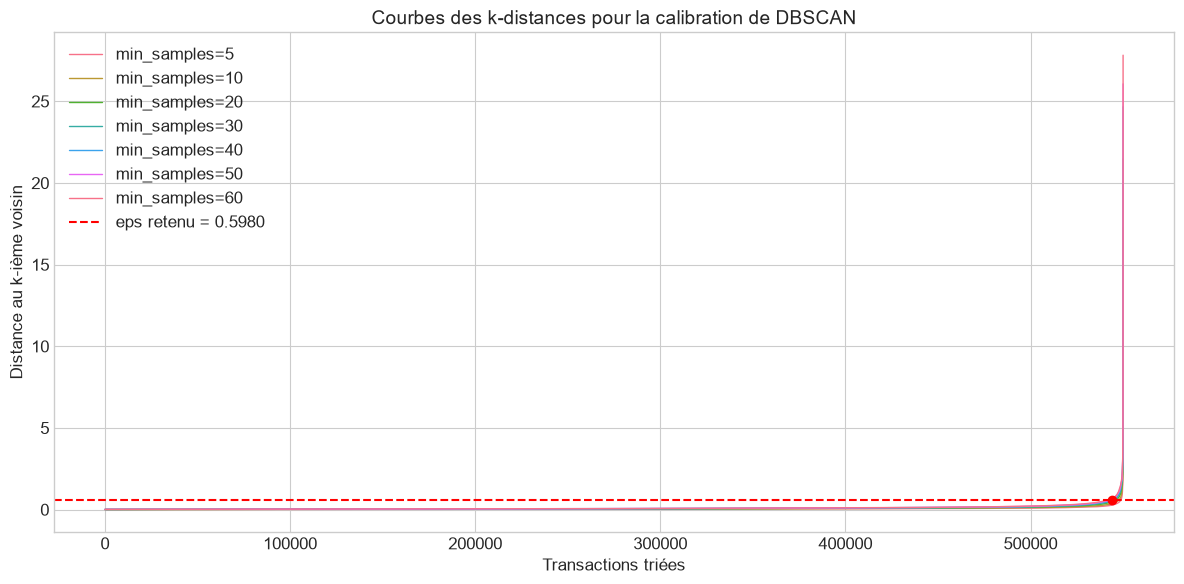


Paramètres retenus : min_samples=40, eps=0.5980
Graphique sauvegardé : '../results/figures/dbscan_k_distances.png'

Paramètres du modèle DBSCAN :
   - metric: euclidean
   - min_samples_candidates: [5, 10, 20, 30, 40, 50, 60]
   - min_samples: 40
   - eps: 0.5979817290178147


In [9]:
"""
    
    Cette section charge et complète la configuration DBSCAN.
    Les hyperparamètres eps et min_samples ne sont pas fixés a priori, ils sont
    calibrés ci-dessous par les courbes des k-distances sur toutes les données AFDM.

"""

def load_dbscan_config(config_path: str = '../configs/config.yml') -> tuple:

    """
        Charge les paramètres DBSCAN avec des valeurs par défaut sûres.

        retournes:
            tuple: config , dbscan_config

    """

    defaults = {
        'metric': 'euclidean',
        'min_samples_candidates': [5, 10,20, 30,40,50,60],
    }

    try:
        with open(config_path, 'r', encoding='utf-8') as file:
            config = yaml.safe_load(file) or {}
        print('Configuration chargée avec succès')
    except FileNotFoundError:
        print(f'Fichier de configuration non trouvé : {config_path}')
        print('Utilisation des paramètres par défaut')
        config = {}

    dbscan_config = {**defaults, **config.get('dbscan', {})}
    candidates = dbscan_config['min_samples_candidates']
    if not all(isinstance(value, int) and value >= 2 for value in candidates):
        raise ValueError('Chaque candidat min_samples doit être un entier supérieur ou égal à 2.')
    print(f"Candidats min_samples chargés : {candidates}")

    return config, dbscan_config


def _find_knee(sorted_distances: np.ndarray) -> tuple:

    """
        Détecte le coude maximal par sa distance à la droite des extrémités.

        retournes:
            tuple: knee_index, distances_to_line
    """
    x = np.linspace(0, 1, len(sorted_distances))
    y_range = sorted_distances[-1] - sorted_distances[0]
    y = (sorted_distances - sorted_distances[0]) / y_range if y_range else np.zeros_like(x)
    # La distance a cette droite est maximale au changement de pente (le coude).
    distances_to_line = np.abs(y - x) / np.sqrt(2)
    knee_index = int(np.argmax(distances_to_line))

    return knee_index, float(distances_to_line[knee_index])


def calibrate_dbscan_kdistances(X_reduced: np.ndarray, config: dict) -> dict:
    
    """ 
        Cette fonction  choisit min_samples et eps à partir des k-distances calculées sur toutes les lignes.
        Pour chaque valeur candidate de min_samples, la distance au k-ième voisin est triée.
        La valeur candidate dont la courbe présente le coude le plus net est retenu, eps est
        alors égal à la k-distance située à ce coude.

        retourne:
            dict: config
    """

    print('\n' + '=' * 60)
    print('7. CALIBRATION DBSCAN PAR LES K-DISTANCES')
    print('=' * 60)

    candidates = sorted(set(config['min_samples_candidates']))
    candidates = [value for value in candidates if value <= len(X_reduced)]
    if not candidates:
        raise ValueError('Aucun candidat min_samples n’est compatible avec la taille des données.')

    curves, results = {}, []
    for min_samples in candidates:
        print(f'Calcul des k-distances pour min_samples={min_samples}...')
        neighbors = NearestNeighbors(
            n_neighbors=min_samples, metric=config['metric'], algorithm='ball_tree', n_jobs=-1
        ).fit(X_reduced)
        distances, _ = neighbors.kneighbors(X_reduced)
        k_distances = np.sort(distances[:, -1])
        knee_index, knee_strength = _find_knee(k_distances)
        curves[min_samples] = (k_distances, knee_index)
        results.append({
            'min_samples': min_samples,
            'eps': float(k_distances[knee_index]),
            'knee_strength': knee_strength
        })

    best = max(results, key=lambda result: result['knee_strength'])
    config['min_samples'] = best['min_samples']
    config['eps'] = best['eps']

    # graphique
    fig, ax = plt.subplots(figsize=(12, 6))
    _, best_knee_index = curves[config['min_samples']]
    for min_samples, (k_distances, _) in curves.items():
        ax.plot(k_distances, linewidth=1, label=f'min_samples={min_samples}')
    ax.axhline(config['eps'], color='red', linestyle='--',
               label=f"eps retenu = {config['eps']:.4f}")
    ax.scatter(best_knee_index, config['eps'], color='red', zorder=3)
    ax.set_title('Courbes des k-distances pour la calibration de DBSCAN')
    ax.set_xlabel('Transactions triées')
    ax.set_ylabel('Distance au k-ième voisin')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/dbscan_k_distances.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nParamètres retenus : min_samples={config['min_samples']}, eps={config['eps']:.4f}")
    print("Graphique sauvegardé : '../results/figures/dbscan_k_distances.png'")

    return config


config, dbscan_config = load_dbscan_config()
dbscan_config = calibrate_dbscan_kdistances(X_reduced, dbscan_config)

print('\nParamètres du modèle DBSCAN :')
for key, value in dbscan_config.items():
    print(f'   - {key}: {value}')


### SECTION 6.2: ENTRAÎNEMENT DU MODÈLE

In [10]:


def train_dbscan(X_reduced: np.ndarray, config: dict) -> tuple:

    """
        Cette fonction entraîne DBSCAN sur les données déjà réduites par la AFDM.
        Le label -1 est le bruit selon DBSCAN, il est interprété ici
        comme une anomalie potentielle. Les autres labels correspondent à des groupes
        denses. 

        retournes:
          tuple: model, labels

    """
    print('\n' + '=' * 60)
    print('ENTRAÎNEMENT DU MODÈLE DBSCAN')
    print('=' * 60)

    print(f'Jeu complet utilisé pour DBSCAN : {len(X_reduced):,} transactions')

    # on passe les parametres à DBSCANB
    model = DBSCAN(
        eps=config['eps'],
        min_samples=config['min_samples'],
        metric=config['metric'],
        algorithm='ball_tree',
        n_jobs=-1
    )

    # on entraine le model
    print('\nEntraînement du modèle...')
    labels = model.fit_predict(X_reduced)

    n_anomalies = int(np.sum(labels == -1))
    n_clusters = len(set(labels)) - int(-1 in labels)
    pct_anomalies = n_anomalies / len(labels) * 100
    print('\n Résultats de la détection :')
    print(f'   Clusters denses détectés : {n_clusters:,}')
    print(f'   Transactions normales : {len(labels) - n_anomalies:,}')
    print(f'   Anomalies potentielles (bruit, label -1) : {n_anomalies:,} ({pct_anomalies:.2f}%)')

    # Le bundle conserve l'AFDM et les paramètres calibrés pour assurer la traçabilité
    artifact = {
        'dbscan_model': model,
        'famd': famd_model,
        'config': config,
        'feature_names': numeric_features + categorical_features,
    }
    joblib.dump(artifact, '../models/dbscan_famd.pkl')
    print("\nModèle et AFDM sauvegardés : '../models/dbscan_famd.pkl'")

    return model, labels

dbscan_model, dbscan_labels = train_dbscan(
    X_reduced, dbscan_config
)



ENTRAÎNEMENT DU MODÈLE DBSCAN
Jeu complet utilisé pour DBSCAN : 550,000 transactions

Entraînement du modèle...

 Résultats de la détection :
   Clusters denses détectés : 6
   Transactions normales : 546,729
   Anomalies potentielles (bruit, label -1) : 3,271 (0.59%)

Modèle et FAMD sauvegardés : '../models/dbscan_famd.pkl'


### SECTION 7 : VISUALISATION DES CLUSTERS DBSCAN

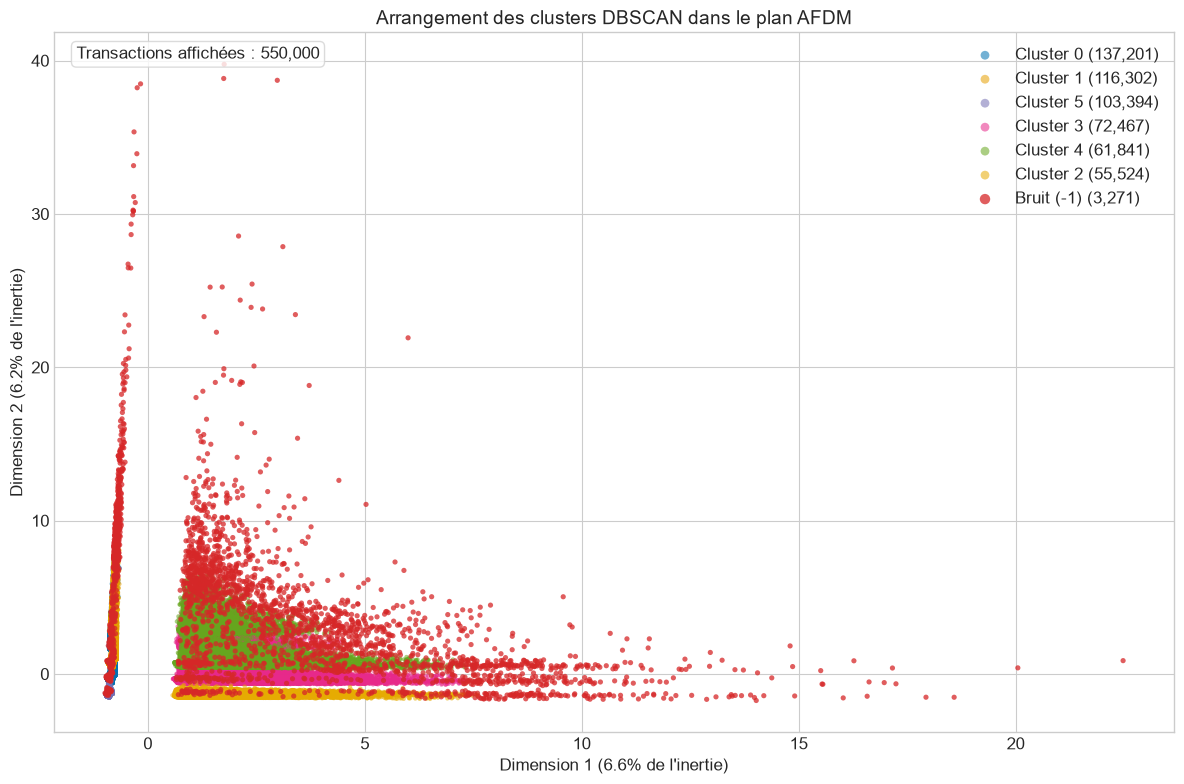

Visualisation des clusters sauvegardée : '../results/figures/dbscan_clusters_famd_2d.png'


In [11]:
"""
Cette visualisation projette les transactions sur les deux premières composantes AFDM
et colore les points selon le cluster attribué par DBSCAN. Le label -1 correspond au
bruit, c'est-à-dire aux anomalies potentielles.
"""
def visualize_dbscan_clusters_2d(
    X_reduced: pd.DataFrame,
    labels: np.ndarray,
    famd_model,
    sample_size: int = 550000,
    random_state: int = 42
) -> None:
    """
    Affiche les clusters DBSCAN dans le plan FAMD.
    """

    labels = np.asarray(labels)
    if len(X_reduced) != len(labels):
        raise ValueError('X_reduced et labels doivent avoir le même nombre de lignes.')
    if X_reduced.shape[1] < 2:
        raise ValueError('La visualisation 2D nécessite au moins deux composantes FAMD.')

    projection_2d = X_reduced.iloc[:, :2].to_numpy()
    explained_inertia = getattr(famd_model, 'percentage_of_variance_', None)
    if explained_inertia is not None:
        explained_inertia = np.asarray(explained_inertia, dtype=float) / 100
    else:
        explained_inertia = getattr(famd_model, 'explained_inertia_', None)
        if explained_inertia is not None:
            explained_inertia = np.asarray(explained_inertia, dtype=float)
    if explained_inertia is not None and len(explained_inertia) >= 2:
        dim1_variance, dim2_variance = explained_inertia[:2]
    else:
        dim1_variance, dim2_variance = 0.0, 0.0

    if len(labels) > sample_size:
        rng = np.random.default_rng(random_state)
        noise_index = np.flatnonzero(labels == -1)
        cluster_index = np.flatnonzero(labels != -1)

        if len(noise_index) >= sample_size:
            sample_index = rng.choice(noise_index, size=sample_size, replace=False)
        else:
            remaining = sample_size - len(noise_index)
            cluster_sample = rng.choice(cluster_index, size=min(remaining, len(cluster_index)), replace=False)
            sample_index = np.concatenate([noise_index, cluster_sample])
        sample_note = f'Echantillon affiché : {len(sample_index):,} / {len(labels):,} transactions'
    else:
        sample_index = np.arange(len(labels))
        sample_note = f'Transactions affichées : {len(labels):,}'

    projection_plot = projection_2d[sample_index]
    labels_plot = labels[sample_index]
    cluster_labels = sorted(label for label in np.unique(labels_plot) if label != -1)
    cluster_sizes = {label: int(np.sum(labels_plot == label)) for label in cluster_labels}
    clusters_by_size_desc = sorted(cluster_labels, key=lambda label: cluster_sizes[label], reverse=True)

    fig, ax = plt.subplots(figsize=(12, 8))
    cluster_colors = {
        0: '#0072B2',
        1: '#E69F00',
    }
    fallback_palette = sns.color_palette('Dark2', n_colors=max(len(cluster_labels), 1))

    for color_index, cluster_label in enumerate(clusters_by_size_desc):
        mask = labels_plot == cluster_label
        color = cluster_colors.get(cluster_label, fallback_palette[color_index % len(fallback_palette)])
        ax.scatter(
            projection_plot[mask, 0],
            projection_plot[mask, 1],
            s=10,
            alpha=0.55,
            color=color,
            edgecolors='none',
            label=f'Cluster {cluster_label} ({cluster_sizes[cluster_label]:,})'
        )

    noise_mask = labels_plot == -1
    if np.any(noise_mask):
        ax.scatter(
            projection_plot[noise_mask, 0],
            projection_plot[noise_mask, 1],
            s=14,
            alpha=0.75,
            color='#d62728',
            edgecolors='none',
            label=f'Bruit (-1) ({int(np.sum(noise_mask)):,})'
        )

    ax.set_title('Arrangement des clusters DBSCAN dans le plan AFDM')
    ax.set_xlabel(f'Dimension 1 ({dim1_variance:.1%} de l\'inertie)')
    ax.set_ylabel(f'Dimension 2 ({dim2_variance:.1%} de l\'inertie)')
    ax.text(
        0.02, 0.98, sample_note,
        transform=ax.transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
    )
    ax.legend(loc='best', markerscale=2)

    plt.tight_layout()
    output_path = '../results/figures/dbscan_clusters_famd_2d.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Visualisation des clusters sauvegardée : '{output_path}'")


visualize_dbscan_clusters_2d(X_reduced, dbscan_labels, famd_model)


### 8 CALCULE DES METRIQUES

#### score de Silouhette, davies Boudlin ,Rapport de classification 

In [ ]:
def metrics_dbscan(
    X_reduced,
    labels,
    sample_size=550_000,
    random_state=42
):
    """
    Calcule les métriques internes de validation de DBSCAN sur une partie du dataset.

    Le bruit DBSCAN (label -1) est exclu du calcul des indices,
    car il ne constitue pas un cluster.

    Parameters
    ----------
    X_reduced : pandas.DataFrame ou numpy.ndarray
        Coordonnées AFDM utilisées pour entraîner DBSCAN.

    labels : array-like
        Labels produits par DBSCAN (-1 = bruit).

    sample_size : int, default=550_000
        Nombre maximal de transactions en cluster utilisées pour
        calculer les métriques. L'échantillonnage évite un calcul
        trop coûteux sur le jeu complet.

    random_state : int, default=42
        Graine assurant la reproductibilité de l'échantillonnage.

    Returns
    -------
    pandas.DataFrame
        Tableau contenant les métriques calculées.
    """

    # Conversion et validation
    X = np.asarray(X_reduced)
    labels = np.asarray(labels).reshape(-1)

    if X.ndim != 2:
        raise ValueError(
            "X_reduced doit être une matrice à deux dimensions."
        )

    if len(X) != len(labels):
        raise ValueError(
            "X_reduced et labels doivent avoir le même nombre de lignes."
        )

    if sample_size < 2:
        raise ValueError(
            "sample_size doit être supérieur ou égal à 2."
        )

    # Informations générales sur DBSCAN
    noise_mask = labels == -1
    cluster_mask = ~noise_mask

    n_total = len(labels)
    n_noise = int(noise_mask.sum())
    n_clustered = int(cluster_mask.sum())

    cluster_labels = np.unique(labels[cluster_mask])
    n_clusters = len(cluster_labels)

    noise_rate = 100 * n_noise / n_total

    print("=" * 60)
    print("MÉTRIQUES INTERNES DE VALIDATION — DBSCAN")
    print("=" * 60)
    print(f"Nombre total de transactions : {n_total:,}")
    print(f"Nombre de clusters : {n_clusters:,}")
    print(f"Points dans les clusters : {n_clustered:,}")
    print(f"Points de bruit : {n_noise:,} ({noise_rate:.2f}%)")

    # Ces métriques exigent au moins deux clusters
    if n_clusters < 2:
        print(
            "\nCalcul impossible : au moins deux clusters "
            "hors bruit sont nécessaires."
        )

        return pd.DataFrame([{
            "nombre_clusters": n_clusters,
            "nombre_bruit": n_noise,
            "taux_bruit_pct": noise_rate,
            "taille_echantillon": 0,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }])

    # Exclusion du bruit
    X_clusters = X[cluster_mask]
    labels_clusters = labels[cluster_mask]

    # Échantillonnage reproductible pour maîtriser le coût,
    # surtout celui du score de silhouette
    if len(X_clusters) > sample_size:
        rng = np.random.default_rng(random_state)

        sample_indices = rng.choice(
            len(X_clusters),
            size=sample_size,
            replace=False
        )

        X_evaluation = X_clusters[sample_indices]
        labels_evaluation = labels_clusters[sample_indices]

    else:
        X_evaluation = X_clusters
        labels_evaluation = labels_clusters

    # Vérification après échantillonnage
    n_sample_clusters = len(np.unique(labels_evaluation))

    if n_sample_clusters < 2:
        raise ValueError(
            "L'échantillon ne contient pas au moins deux clusters. "
            "Augmentez sample_size."
        )

    # Calcul des métriques
    silhouette = silhouette_score(
        X_evaluation,
        labels_evaluation,
        metric=dbscan_config.get("metric", "euclidean")
    )

    davies_bouldin = davies_bouldin_score(
        X_evaluation,
        labels_evaluation
    )

    calinski_harabasz = calinski_harabasz_score(
        X_evaluation,
        labels_evaluation
    )

    results = pd.DataFrame([{
        "nombre_clusters": n_clusters,
        "nombre_bruit": n_noise,
        "taux_bruit_pct": noise_rate,
        "taille_echantillon": len(X_evaluation),
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz
    }])

    print(f"\nTaille de l'échantillon : {len(X_evaluation):,}")
    print(f"Score de silhouette : {silhouette:.4f}")
    print(f"Indice de Davies-Bouldin : {davies_bouldin:.4f}")
    print(f"Indice de Calinski-Harabasz : {calinski_harabasz:.4f}")

    print("\nInterprétation :")
    print("  - Silhouette : plus proche de 1 = meilleure séparation")
    print("  - Davies-Bouldin : plus faible = meilleur résultat")
    print("  - Calinski-Harabasz : plus élevé = meilleur résultat")

    return results

#execution
dbscan_internal_metrics = metrics_dbscan(
    X_reduced=X_reduced,
    labels=dbscan_labels,
    sample_size=550_000,
    random_state=42
)

display(dbscan_internal_metrics.round(4))

MÉTRIQUES INTERNES DE VALIDATION — DBSCAN
Nombre total de transactions : 550,000
Nombre de clusters : 6
Points dans les clusters : 546,729
Points de bruit : 3,271 (0.59%)


### SECTION 8 : ANALYSE DES RÉSULTATS

In [ ]:
"""

    Cette section analyse les résultats du modèle DBSCAN.

    INDICATEURS ANALYSÉS:
        - Nombre d'anomalie potentielle détectée
        - Proportion d'anomalies par rapport au total
        - Distribution des clusters DBSCAN
        - Statistiques des variables pour les anomalies vs normales
"""

def analyze_results(df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    """
    Analyse les résultats du modèle modèle DBSCAN.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame original
    labels : np.ndarray
        Labels DBSCAN (-1 = bruit/anomalie potentielle, 0, 1, ... = clusters)
        
    Returns
    -------
    pd.DataFrame
        DataFrame original enrichi avec les labels DBSCAN.
        
    """
    
    print("\n" + "="*60)
    print("10. ANALYSE DES RÉSULTATS")
    print("="*60)
    
    labels = np.asarray(labels)
    if len(df) != len(labels):
        raise ValueError('df et labels doivent avoir le même nombre de lignes.')

    # Ajouter les labels DBSCAN au DataFrame
    df_result = df.copy()
    df_result['dbscan_cluster'] = labels
    df_result['dbscan_anomaly'] = np.where(labels == -1, -1, 1)
    
    # Séparer normales et anomalies
    normal = df_result[df_result['dbscan_anomaly'] == 1]
    anomalies = df_result[df_result['dbscan_anomaly'] == -1]
    
    print("\n8.1 STATISTIQUES GLOBALES:")
    print("-"*40)
    print(f"   - Total: {len(df_result):,}")
    print(f"   - Normales: {len(normal):,} ({len(normal)/len(df_result)*100:.2f}%)")
    print(f"   - Anomalies: {len(anomalies):,} ({len(anomalies)/len(df_result)*100:.2f}%)")
    print(f"   - Clusters denses détectés: {df_result.loc[df_result['dbscan_cluster'] != -1, 'dbscan_cluster'].nunique():,}")

    print("\n10.2 DISTRIBUTION DES CLUSTERS DBSCAN:")
    print("-"*40)
    cluster_distribution = (
        df_result['dbscan_cluster']
        .value_counts()
        .sort_index()
        .rename_axis('Cluster')
        .reset_index(name='Nombre')
    )
    cluster_distribution['Pourcentage'] = cluster_distribution['Nombre'] / len(df_result) * 100
    display(cluster_distribution.round(2))
    
    print("\n10.3 STATISTIQUES DES VARIABLES (ANOMALIES VS NORMALES):")
    print("-"*40)
    
    variables = ['transaction_amount', 'account_balance', 'credit_score', 'has_loan', 'emi_amount', 'transaction_hour']
    
    stats = []
    for var in variables:
        stats.append({
            'Variable': var,
            'Moyenne_Normal': normal[var].mean(),
            'Moyenne_Anomalie': anomalies[var].mean(),
            'Écart_Normal': normal[var].std(),
            'Écart_Anomalie': anomalies[var].std()
        })
    
    stats_df = pd.DataFrame(stats)
    display(stats_df.round(2))
    
    # Sauvegarde
    stats_df.to_csv('../results/metrics/dbscan_stats.csv', index=False)
    cluster_distribution.to_csv('../results/metrics/dbscan_cluster_distribution.csv', index=False)
    print("\nStatistiques sauvegardées : '../results/metrics/dbscan_stats.csv'")
    print("Distribution des clusters sauvegardée : '../results/metrics/dbscan_cluster_distribution.csv'")
    
    return df_result

df_result = analyze_results(df, dbscan_labels)

### SECTION 9 : EXPORT DES ANOMALIES DÉTECTÉES

In [ ]:
"""
    Cette section exporte les anomalies détectées pour analyse ultérieure.

    FICHIERS EXPORTÉS:
        - detected_anomalies_dbscan.csv: Toutes les anomalies détectées
        - dbscan_anomalies_summary.csv: Résumé statistique des anomalies détectées
"""

def export_anomalies(df_result: pd.DataFrame) -> None:
    """
    Exporte les anomalies détectées dans des fichiers CSV.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame avec les prédictions
        
    Returns
    -------
    None
        Les fichiers sont sauvegardés dans le dossier results/anomalies/
        
    Examples
    --------
    >>> export_anomalies(df_result)
    """
    
    print("\n" + "="*60)
    print("11. EXPORT DES ANOMALIES DÉTECTÉES")
    print("="*60)
    
    # Créer le dossier
    Path('../results/anomalies').mkdir(parents=True, exist_ok=True)
    
    if 'dbscan_anomaly' not in df_result.columns:
        raise ValueError("La colonne 'dbscan_anomaly' est absente. Exécutez d'abord la section 10.")
    
    # Extraire les anomalies potentielles DBSCAN (label -1)
    anomalies = df_result[df_result['dbscan_anomaly'] == -1].copy()
    anomalies.to_csv('../results/anomalies/detected_anomalies_dbscan.csv', index=False)
    print(f"Anomalies exportées: {len(anomalies):,}")
    print("   - '../results/anomalies/detected_anomalies_dbscan.csv'")
    
    # Créer un résumé des anomalies
    summary = anomalies.describe(include='all')
    summary.to_csv('../results/metrics/dbscan_anomalies_summary.csv')
    print("   - '../results/metrics/dbscan_anomalies_summary.csv'")

export_anomalies(df_result)

### SECTION 10 : SYNTHÈSE ET RECOMMANDATIONS

In [ ]:
"""
Cette section résume les résultats obtenus avec DBSCAN et formule
des recommandations pour l'exploitation des anomalies potentielles.

PRINCIPAUX RÉSULTATS:
    - Nombre de clusters denses détectés
    - Nombre et proportion de transactions classées comme bruit
    - Nombre et proportion de transactions appartenant aux clusters
    - Taille des principaux clusters
    - Caractéristiques des anomalies potentielles

RECOMMANDATIONS:
    - Validation des anomalies avec des experts métier
    - Réévaluation des paramètres eps et min_samples
    - Analyse de la stabilité des clusters
    - Comparaison avec Isolation Forest
    - Surveillance du taux de faux positifs

IMPORTANT:
    Le label -1 de DBSCAN représente du bruit statistique.
    Il ne correspond pas automatiquement à une fraude confirmée.
"""


def generate_dbscan_summary(
    df: pd.DataFrame,
    labels: np.ndarray,
    report_path: str = "../results/metrics/dbscan_report.txt"
) -> None:
    """
    Génère une synthèse des résultats du modèle DBSCAN.

    Parameters
    ----------
    df : pd.DataFrame
        Données originales utilisées pour l'analyse.

    labels : numpy.ndarray
        Labels produits par DBSCAN. Le label -1 représente le bruit.

    report_path : str, default="../results/metrics/dbscan_report.txt"
        Chemin du rapport texte à sauvegarder.

    Returns
    -------
    None
        La synthèse est affichée et sauvegardée.

    Examples
    --------
    >>> generate_dbscan_summary(df, dbscan_labels)
    """

    # ===========================================================
    # Validation des donnees
    # ===========================================================

    labels = np.asarray(labels).reshape(-1)

    if len(df) == 0:
        raise ValueError("Le DataFrame fourni est vide.")

    if len(labels) == 0:
        raise ValueError("Le tableau de labels est vide.")

    if len(df) != len(labels):
        raise ValueError(
            "Le DataFrame et les labels doivent avoir la même taille : "
            f"df={len(df):,}, labels={len(labels):,}."
        )

    # ===========================================================
    # Calcul des resultats generaux
    # ===========================================================

    n_total = len(labels)
    noise_mask = labels == -1
    normal_mask = labels != -1

    n_anomalies = int(np.count_nonzero(noise_mask))
    n_normales = int(np.count_nonzero(normal_mask))

    pct_anomalies = 100 * n_anomalies / n_total
    pct_normales = 100 * n_normales / n_total

    cluster_labels = np.unique(labels[normal_mask])
    n_clusters = len(cluster_labels)

    cluster_sizes = (
        pd.Series(labels[normal_mask], name="cluster")
        .value_counts()
        .sort_values(ascending=False)
    )

    # Vérification des calculs
    if n_anomalies + n_normales != n_total:
        raise RuntimeError(
            "Incohérence dans le comptage des transactions."
        )

    if not np.isclose(
        pct_anomalies + pct_normales,
        100.0,
        atol=1e-10
    ):
        raise RuntimeError(
            "Les pourcentages ne totalisent pas 100 %."
        )

    # ===========================================================
    # Preparation des groupes
    # -----------------------------------------------------------

    df_analysis = df.copy()
    df_analysis["dbscan_cluster"] = labels
    # Même convention que dans la section 10 : -1 = bruit, 1 = cluster.
    df_analysis["dbscan_anomaly"] = np.where(noise_mask, -1, 1)

    anomalies = df_analysis.loc[noise_mask]
    normales = df_analysis.loc[normal_mask]

    candidate_numeric_variables = [
        "transaction_amount",
        "account_balance",
        "credit_score",
        "has_loan",
        "emi_amount",
        "transaction_hour"
    ]

    numeric_variables = [
        variable
        for variable in candidate_numeric_variables
        if variable in df_analysis.columns
    ]

    candidate_categorical_variables = [
        "channel",
        "account_type",
        "transaction_type",
        "transaction_direction"
    ]

    categorical_variables = [
        variable
        for variable in candidate_categorical_variables
        if variable in df_analysis.columns
    ]

    # ===========================================================
    # Construction du rapport
    # ===========================================================

    report_lines = []

    def add_line(text=""):
        
        """
            Ajoute une ligne à l'affichage et au rapport.
        
        """
        print(text)
        report_lines.append(text)

    add_line("\n" + "=" * 60)
    add_line("12. SYNTHÈSE ET RECOMMANDATIONS — DBSCAN")
    add_line("=" * 60)

    add_line("\n12.1 PRINCIPAUX RÉSULTATS:")
    add_line("-" * 40)
    add_line(f"   - Total des transactions : {n_total:,}")
    add_line(f"   - Nombre de clusters denses : {n_clusters:,}")
    add_line(
        f"   - Anomalies potentielles (bruit) : "
        f"{n_anomalies:,} ({pct_anomalies:.2f}%)"
    )
    add_line(
        f"   - Transactions dans les clusters : "
        f"{n_normales:,} ({pct_normales:.2f}%)"
    )
    add_line(
        f"   - Vérification des pourcentages : "
        f"{pct_anomalies + pct_normales:.2f}%"
    )

    # ===========================================================
    # Taille des principaux clusters
    # ===========================================================

    add_line("\n12.2 RÉPARTITION DES CLUSTERS:")
    add_line("-" * 40)

    if cluster_sizes.empty:
        add_line("   - Aucun cluster dense détecté.")
    else:
        add_line("   - Dix principaux clusters :")

        for cluster_id, cluster_size in cluster_sizes.head(10).items():
            cluster_pct = 100 * cluster_size / n_total

            add_line(
                f"      - Cluster {cluster_id}: "
                f"{cluster_size:,} transactions "
                f"({cluster_pct:.2f}% du total)"
            )

        if n_clusters > 10:
            add_line(
                f"   - Autres clusters non affichés : "
                f"{n_clusters - 10:,}"
            )

    # ===========================================================
    # Caracteristiques des anomalies
    # ==========================================================

    add_line("\n12.3 CARACTÉRISTIQUES NUMÉRIQUES DES ANOMALIES POTENTIELLES:")
    add_line("-" * 40)

    if n_anomalies == 0:
        add_line(
            "   DBSCAN n'a classé aucune transaction comme bruit."
        )

    elif n_normales == 0:
        add_line(
            "   Toutes les transactions ont été classées comme bruit."
        )
        add_line(
            "    Les paramètres eps et min_samples doivent être révisés."
        )

    elif not numeric_variables:
        add_line(
            "   Aucune variable numérique prévue n'est disponible."
        )

    else:
        for variable in numeric_variables:
            normal_values = pd.to_numeric(
                normales[variable],
                errors="coerce"
            )

            anomaly_values = pd.to_numeric(
                anomalies[variable],
                errors="coerce"
            )

            normal_mean = normal_values.mean()
            anomaly_mean = anomaly_values.mean()
            difference = anomaly_mean - normal_mean

            normal_median = normal_values.median()
            anomaly_median = anomaly_values.median()

            add_line(f"\n   {variable}:")
            add_line(
                f"      - Moyenne des transactions en cluster : "
                f"{normal_mean:,.2f}"
            )
            add_line(
                f"      - Moyenne du bruit DBSCAN : "
                f"{anomaly_mean:,.2f}"
            )
            add_line(
                f"      - Écart des moyennes : "
                f"{difference:,.2f}"
            )
            add_line(
                f"      - Médiane des transactions en cluster : "
                f"{normal_median:,.2f}"
            )
            add_line(
                f"      - Médiane du bruit DBSCAN : "
                f"{anomaly_median:,.2f}"
            )

    # ===========================================================
    # Variables catégorielles utilisées par l'AFDM
    # ===========================================================

    add_line("\n12.4 CARACTÉRISTIQUES CATÉGORIELLES DES ANOMALIES POTENTIELLES:")
    add_line("-" * 40)

    if n_anomalies == 0 or n_normales == 0:
        add_line("   - Comparaison impossible en l'absence des deux groupes.")
    elif not categorical_variables:
        add_line("   - Aucune variable catégorielle prévue n'est disponible.")
    else:
        for variable in categorical_variables:
            modality_summary = (
                df_analysis.groupby(variable, dropna=False)
                .agg(
                    total=("dbscan_cluster", "size"),
                    bruit_dbscan=("dbscan_cluster", lambda values: (values == -1).sum())
                )
            )
            modality_summary["taux_bruit_pct"] = (
                100 * modality_summary["bruit_dbscan"] / modality_summary["total"]
            )
            modality_summary = modality_summary.sort_values(
                "taux_bruit_pct", ascending=False
            )

            add_line(f"\n   {variable} — taux de bruit par modalité:")
            for modality, row in modality_summary.iterrows():
                add_line(
                    f"      - {modality}: {int(row['bruit_dbscan']):,} / "
                    f"{int(row['total']):,} ({row['taux_bruit_pct']:.2f}%)"
                )

    # ===========================================================
    # Recommandations
    # ===========================================================

    add_line("\n12.5 RECOMMANDATIONS:")
    add_line("-" * 40)

    add_line("   1. VALIDATION MÉTIER:")
    add_line(
        "      - Soumettre un échantillon du bruit DBSCAN "
        "aux experts bancaires."
    )
    add_line(
        "      - Ne pas assimiler automatiquement le label -1 "
        "à une fraude confirmée."
    )
    add_line(
        "      - Identifier les faux positifs et les fraudes manquées."
    )
    add_line(
        "      - Examiner avec les experts les modalités catégorielles "
        "présentant les taux de bruit les plus élevés."
    )

    add_line("\n   2. AJUSTEMENT DU MODÈLE:")
    add_line(
        "      - Comparer plusieurs valeurs de eps et min_samples."
    )
    add_line(
        "      - Examiner le taux de bruit et le nombre de clusters "
        "pour chaque configuration."
    )
    add_line(
        "      - Vérifier la stabilité des résultats sur plusieurs "
        "échantillons."
    )
    add_line(
        "      - Comparer les dimensions FAMD candidates "
        "(11, 16, 17, 18, 19 et 20 composantes)."
    )

    if n_clusters > 100:
        add_line(
            f"      - Le nombre de clusters ({n_clusters:,}) est élevé; "
            "cela peut indiquer une fragmentation excessive."
        )
        add_line(
            "      - Tester une valeur de eps légèrement plus grande "
            "ou revoir la réduction FAMD."
        )

    add_line("\n   3. VALIDATION CROISÉE:")
    add_line(
        "      - Comparer les anomalies DBSCAN avec celles "
        "d'Isolation Forest."
    )
    add_line(
        "      - Accorder une priorité plus élevée aux transactions "
        "signalées par les deux modèles."
    )
    if "is_fraud" in df_analysis.columns:
        add_line(
            "      - Exploiter la variable is_fraud disponible pour calculer "
            "précision, rappel, F1-score et matrice de confusion."
        )
        add_line(
            "      - Mesurer explicitement les faux positifs et les fraudes "
            "non détectées par le bruit DBSCAN."
        )
    else:
        add_line(
            "      - Si une étiquette de fraude devient disponible, calculer "
            "précision, rappel, F1-score et matrice de confusion."
        )

    add_line("\n   4. AMÉLIORATION CONTINUE:")
    add_line(
        "      - Réévaluer régulièrement la distribution des données."
    )
    add_line(
        "      - Recalibrer DBSCAN lorsque les comportements "
        "transactionnels évoluent."
    )
    add_line(
        "      - Conserver la configuration, la date et la version "
        "des données pour assurer la traçabilité."
    )

    # ===========================================================
    # Sauvegarde
    # ===========================================================

    report_file = Path(report_path)
    report_file.parent.mkdir(parents=True, exist_ok=True)

    report_header = [
        "=" * 60,
        "RAPPORT DBSCAN — DÉTECTION D'ANOMALIES",
        "=" * 60,
        "",
        f"Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        ""
    ]

    report_file.write_text(
        "\n".join(report_header + report_lines).strip() + "\n",
        encoding="utf-8"
    )

    print(f"\nRapport sauvegardé : '{report_file}'")


generate_dbscan_summary(df, dbscan_labels)

### CONCLUSION

  RÉSULTATS PRODUITS:
        -------------------

        1. MODÈLE:
                - ../models/dbscan_famd.pkl

        2. VISUALISATIONS:
                - ../results/figures/famd_projection_2d.png


                - ../results/figures/dbscan_k_distances.png
                - ../results/figures/dbscan_clusters_famd_2d.png

        3. MÉTRIQUES ET RAPPORTS:
                - ../results/metrics/dbscan_stats.csv
                - ../results/metrics/dbscan_cluster_distribution.csv
                - ../results/metrics/dbscan_anomalies_summary.csv
                  

        4. ANOMALIES:
                - ../results/anomalies/detected_anomalies_dbscan.csv

        
---